# Introduction to Feature Scaling

Feature Scaling is a preprocessing technique used to bring numerical features to a similar scale.

In a dataset, different features can have very different ranges.

For example:

- Age → 18 to 80
- Salary → 20,000 to 500,000
- Experience → 0 to 30

A machine learning algorithm that depends on distance or magnitude may give more importance to features with larger numerical values.

Feature Scaling helps prevent this problem.

## Why Is Feature Scaling Important?

Consider two features:

Age:
20, 30, 40, 50

Salary:
20,000, 50,000, 100,000, 500,000

Although both features may be equally important, Salary has much larger numerical values.

Some machine learning algorithms can therefore be influenced more by Salary.

Scaling transforms the features into comparable numerical ranges.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Age": [20, 25, 30, 35, 40],
    "Salary": [25000, 40000, 60000, 90000, 150000],
    "Experience": [1, 3, 5, 8, 12]
})

df

,Age,Salary,Experience
0,20,25000,1
1,25,40000,3
2,30,60000,5
3,35,90000,8
4,40,150000,12


#### Comparing Feature Ranges

Before scaling, we should examine the range of each numerical feature.

We can use:

- Minimum
- Maximum
- Mean
- Standard deviation

In [2]:
df.describe()

,Age,Salary,Experience
count,5.000000,5.00000,5.00000
mean,30.000000,73000.00000,5.80000
std,7.905694,49446.94126,4.32435
min,20.000000,25000.00000,1.00000
25%,25.000000,40000.00000,3.00000
50%,30.000000,60000.00000,5.00000
75%,35.000000,90000.00000,8.00000
max,40.000000,150000.00000,12.00000


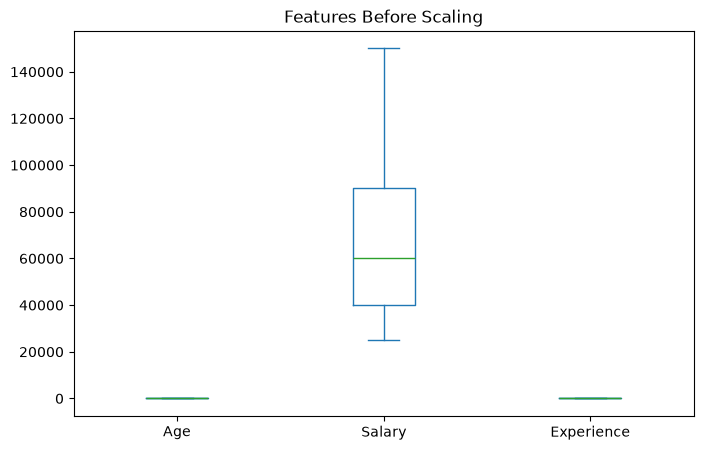

In [3]:
import matplotlib.pyplot as plt

df.plot(
    kind="box",
    figsize=(8, 5)
)

plt.title("Features Before Scaling")
plt.show()

## Main Feature Scaling Techniques

The most commonly used scaling techniques are:

### 1. Standardization
Transforms features so that they have approximately:

Mean = 0
Standard Deviation = 1

Commonly implemented using `StandardScaler`.

### 2. Min-Max Scaling
Transforms values into a specific range, commonly:

0 to 1

Implemented using `MinMaxScaler`.

### 3. Robust Scaling
Uses the median and Interquartile Range (IQR).

Implemented using `RobustScaler`.

### 4. Max Absolute Scaling
Scales values according to the maximum absolute value.

Implemented using `MaxAbsScaler`.

## 1. Standardization

Standardization transforms a feature using:

z = (x - μ) / σ

Where:

- x = Original value
- μ = Mean
- σ = Standard deviation

After standardization, the feature generally has:

Mean ≈ 0
Standard Deviation ≈ 1

Standardization is commonly used when features have approximately normal distributions.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_standardized

,Age,Salary,Experience
0,-1.414214,-1.085318,-1.241010
1,-0.707107,-0.746156,-0.723923
2,0.000000,-0.293940,-0.206835
3,0.707107,0.384383,0.568796
4,1.414214,1.741030,1.602972


## 2. Min-Max Scaling

Min-Max Scaling transforms values into a fixed range.

The common formula is:

x_scaled = (x - x_min) / (x_max - x_min)

The default range is:

0 to 1

This method preserves the relative relationships between observations.

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_minmax

,Age,Salary,Experience
0,0.00,0.00,0.000000
1,0.25,0.12,0.181818
2,0.50,0.28,0.363636
3,0.75,0.52,0.636364
4,1.00,1.00,1.000000


## 3. Robust Scaling

Robust Scaling uses:

- Median
- Interquartile Range (IQR)

Formula:

x_scaled = (x - Median) / IQR

Because it uses the median and IQR instead of the mean and standard deviation, it is less sensitive to outliers.

It can be useful when numerical features contain extreme values.

In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_robust = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_robust

,Age,Salary,Experience
0,-1.0,-0.7,-0.8
1,-0.5,-0.4,-0.4
2,0.0,0.0,0.0
3,0.5,0.6,0.6
4,1.0,1.8,1.4


## 4. Max Absolute Scaling

Max Absolute Scaling divides each feature by its maximum absolute value.

The resulting values are generally between:

-1 and 1

This scaler is useful when working with sparse data because it does not center the data around zero.

In [7]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

df_maxabs = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

df_maxabs

,Age,Salary,Experience
0,0.500,0.166667,0.083333
1,0.625,0.266667,0.250000
2,0.750,0.400000,0.416667
3,0.875,0.600000,0.666667
4,1.000,1.000000,1.000000


In [8]:
print("Original Data:")
display(df)

print("Standardized:")
display(df_standardized)

print("Min-Max Scaled:")
display(df_minmax)

print("Robust Scaled:")
display(df_robust)

print("Max Absolute Scaled:")
display(df_maxabs)

Original Data:


,Age,Salary,Experience
0,20,25000,1
1,25,40000,3
2,30,60000,5
3,35,90000,8
4,40,150000,12


Standardized:


,Age,Salary,Experience
0,-1.414214,-1.085318,-1.241010
1,-0.707107,-0.746156,-0.723923
2,0.000000,-0.293940,-0.206835
3,0.707107,0.384383,0.568796
4,1.414214,1.741030,1.602972


Min-Max Scaled:


,Age,Salary,Experience
0,0.00,0.00,0.000000
1,0.25,0.12,0.181818
2,0.50,0.28,0.363636
3,0.75,0.52,0.636364
4,1.00,1.00,1.000000


Robust Scaled:


,Age,Salary,Experience
0,-1.0,-0.7,-0.8
1,-0.5,-0.4,-0.4
2,0.0,0.0,0.0
3,0.5,0.6,0.6
4,1.0,1.8,1.4


Max Absolute Scaled:


,Age,Salary,Experience
0,0.500,0.166667,0.083333
1,0.625,0.266667,0.250000
2,0.750,0.400000,0.416667
3,0.875,0.600000,0.666667
4,1.000,1.000000,1.000000
